# 07 · 국내 신규의 첫날 활동 영역 — 9/4 vs 9/10

**한 줄 질문:** 9월 10일의 국내 신규 기기가 9월 4일보다 첫날 더 다양한 게임 영역에 도달했나?

**합의한 H3와 사전 판정 기준:** 두 날짜의 `South Korea` 최초 관측 신규 기기 **전체**를 각각 분모로 잡는다. 첫날 5개 영역 중 2개 이상에 도달한 비율이 9/10에서 9/4보다 **15%p 이상** 높으면 H3를 채택하고, 그 미만이면 기각한다. 비율은 탐색적 기술통계이며 작은 표본으로 인과효과를 주장하지 않는다.

이 노트북은 G2 EDA만 수행한다. 모델 학습, 후속 가설 검정, 이벤트 순서 복원은 하지 않는다.

## 1. 모집단·행동·제외 기준

- BigQuery GA4 `events_*` 전체 이력에서 2026-09-11(KST)까지의 완전 일별 export를 사용한다. 9/4·9/10의 **첫 관측일 이벤트만** 행동에 포함한다. 재방문 행동은 넣지 않는다.
- 기기 키는 `user_pseudo_id`. 회전하는 익명 `user_id`는 사람 수로 쓰지 않는다. 첫 이벤트의 `geo.country`가 `South Korea`인 기기만 포함한다.
- 영역 5개: 자연·채집, 낚시·바다, 퀘스트·교류, 제작·집, 고급 콘텐츠. 기존 [06 노트북](06_spike_day_behavior_eda.ipynb)의 검증된 의도적 행동 허용목록과 동일하다. 각 영역 이벤트가 **1회 이상**이면 그 영역에 도달한 것으로 센다.
- 자동 수집, `login`, `session_summary`, `econ_tx`, 과거에 도움말 닫기와 섞인 `tutorial_skip`은 행동에서 제외한다.
- 행동 0 기기도 분모에 그대로 둔다. D1/D7이나 순서/경로를 이번 가설에 쓰지 않는다.

**완료 기준:** 원시 분자·분모 확인, H3 사전 기준 판정, 영역 수 분포·영역 도달·겹침·기기 구성 차트, 한계·다음 점검 기록. 모든 차트는 별도 PNG로 저장하고 이 노트북에 인라인 삽입한다.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))
from calm_ml import bq, report as R, tracking

SQL = ROOT / 'ml/sql/g2_spike_user_behavior.sql'
OUT = ROOT / 'ml/reports/g2_domestic_breadth_2026-09-14'
OUT.mkdir(parents=True, exist_ok=True)
R.setup()

COHORTS = ['09/04 spike', '09/10 spike']
SHORT = {'09/04 spike': '9/4', '09/10 spike': '9/10'}
AREAS = {
    'nature_events': '자연·채집',
    'fishing_sea_events': '낚시·바다',
    'quest_social_events': '퀘스트·교류',
    'craft_home_events': '제작·집',
    'advanced_events': '고급 콘텐츠',
}

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k/n
    d = 1 + z*z/n
    center = (p + z*z/(2*n))/d
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return center-half, center+half


## 2. 실행 SQL 원문

아래 SQL이 유일한 추출 정의다. 기기 식별자는 SQL 내부 중복 제거·조인에만 쓰고 결과에서 제거한다. 9월 14일 재실행해도 9월 11일 기준의 같은 코호트·첫날 행동을 비교하도록 종료일을 고정했다.

In [2]:
display(Markdown('```sql\n' + SQL.read_text(encoding='utf-8') + '\n```'))

```sql
-- G2 spike-day behavior: one anonymous feature row per first-seen GA4 device.
-- The device identifier is used inside CTEs for joins and removed from output.
-- Deliberate actions use the allowlist already audited in 02_churn_where.ipynb;
-- automatic collection, login, ledger, and passive UI events are not actions.
WITH base AS (
  SELECT
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS activity_day,
    event_timestamp,
    user_pseudo_id,
    event_name,
    COALESCE(device.category, '(unknown)') AS device,
    COALESCE(geo.country, '(unknown)') AS country,
    COALESCE(traffic_source.source, '(direct)') AS source,
    COALESCE(traffic_source.medium, '(none)') AS medium
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE user_pseudo_id IS NOT NULL
    AND _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') <= DATE '2026-09-11'
),
first_seen AS (
  SELECT user_pseudo_id, MIN(activity_day) AS first_day
  FROM base
  GROUP BY 1
),
profile AS (
  SELECT
    b.user_pseudo_id,
    ARRAY_AGG(
      STRUCT(b.device AS device, b.country AS country, b.source AS source, b.medium AS medium)
      ORDER BY b.event_timestamp LIMIT 1
    )[OFFSET(0)] AS p
  FROM base b
  GROUP BY 1
),
first_day_events AS (
  SELECT b.*, f.first_day
  FROM base b
  JOIN first_seen f USING (user_pseudo_id)
  WHERE b.activity_day = f.first_day
),
returns AS (
  SELECT
    f.user_pseudo_id,
    LOGICAL_OR(b.activity_day = DATE_ADD(f.first_day, INTERVAL 1 DAY)) AS returned_d1,
    LOGICAL_OR(b.activity_day = DATE_ADD(f.first_day, INTERVAL 7 DAY)) AS returned_d7
  FROM first_seen f
  JOIN base b USING (user_pseudo_id)
  GROUP BY 1
),
features AS (
  SELECT
    e.user_pseudo_id,
    e.first_day,
    CASE
      WHEN e.first_day = DATE '2026-08-15' THEN '08/15 spike'
      WHEN e.first_day = DATE '2026-09-04' THEN '09/04 spike'
      WHEN e.first_day = DATE '2026-09-10' THEN '09/10 spike'
      ELSE 'non-spike'
    END AS cohort,
    p.p.device AS device,
    CASE
      WHEN p.p.country = 'South Korea' THEN 'South Korea'
      WHEN p.p.country = 'United States' THEN 'United States'
      ELSE 'Other'
    END AS country_group,
    CASE
      WHEN LOWER(p.p.source) IN ('(direct)', 'direct')
       AND LOWER(p.p.medium) IN ('(none)', 'none') THEN 'direct / none'
      ELSE 'other acquisition'
    END AS acquisition_group,
    COUNT(*) AS ga4_events,
    TIMESTAMP_DIFF(
      TIMESTAMP_MICROS(MAX(e.event_timestamp)),
      TIMESTAMP_MICROS(MIN(e.event_timestamp)), SECOND
    ) AS observed_span_sec,
    COUNTIF(e.event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    )) AS deliberate_events,
    COUNT(DISTINCT IF(e.event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
      'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
      'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    ), e.event_name, NULL)) AS deliberate_kinds,
    COUNTIF(e.event_name IN (
      'character_select','nickname_set','intro_start','intro_complete','intro_skip',
      'tutorial_start','tutorial_step','tutorial_complete'
    )) AS onboarding_events,
    COUNTIF(e.event_name IN (
      'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick','mine_ore'
    )) AS nature_events,
    COUNTIF(e.event_name IN (
      'fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch','boat_start'
    )) AS fishing_sea_events,
    COUNTIF(e.event_name IN (
      'npc_talk','quest_accept','quest_complete','gift_give'
    )) AS quest_social_events,
    COUNTIF(e.event_name IN (
      'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
      'cooking_start','carve_start'
    )) AS craft_home_events,
    COUNTIF(e.event_name IN (
      'mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
      'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
    )) AS advanced_events
  FROM first_day_events e
  JOIN profile p USING (user_pseudo_id)
  GROUP BY 1, 2, 3, 4, 5, 6
)
SELECT
  f.* EXCEPT(user_pseudo_id),
  f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 1 DAY) AS d1_eligible,
  IF(f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 1 DAY), r.returned_d1, NULL)
    AS returned_d1,
  f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 7 DAY) AS d7_eligible,
  IF(f.first_day <= DATE_SUB(DATE '2026-09-11', INTERVAL 7 DAY), r.returned_d7, NULL)
    AS returned_d7
FROM features f
JOIN returns r USING (user_pseudo_id)
ORDER BY first_day, cohort;

```

## 3. 원시 분자·분모와 H3 판정

먼저 BigQuery에서 9/11 고정 추출을 다시 실행한다. 익명 기기별 결과는 메모리에서만 필터링하며, W&B에는 집계표와 그래프만 보낸다. `activity_area_count`는 다섯 영역 열이 양수인 개수다.

In [3]:
all_devices = bq.read_sql_file(SQL)
domestic = all_devices[
    all_devices.cohort.isin(COHORTS) & all_devices.country_group.eq('South Korea')
].copy()
for field in AREAS:
    domestic[field] = pd.to_numeric(domestic[field], errors='coerce').fillna(0)
domestic['activity_area_count'] = (domestic[list(AREAS)] > 0).sum(axis=1)
domestic['two_plus'] = domestic.activity_area_count >= 2

rows = []
for cohort in COHORTS:
    group = domestic[domestic.cohort.eq(cohort)]
    n = len(group)
    k = int(group.two_plus.sum())
    lo, hi = wilson(k, n)
    rows.append(dict(cohort=SHORT[cohort], devices=n, two_plus=k,
                     rate=k/n if n else np.nan, ci_low=lo, ci_high=hi,
                     no_area=int(group.activity_area_count.eq(0).sum()),
                     one_area=int(group.activity_area_count.eq(1).sum()),
                     two_or_more=k))
summary = pd.DataFrame(rows)
delta = float(summary.iloc[1].rate - summary.iloc[0].rate)
h3_pass = bool(delta >= .15)
summary.to_csv(OUT/'cohort_summary.csv', index=False)
display(summary)
print(f'차이: {delta:.1%}p / 사전 기준: +15.0%p / H3: {"채택" if h3_pass else "기각"}')
print('BigQuery 반환 전체 기기:', len(all_devices), '국내 두 코호트:', len(domestic))


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cohort,devices,two_plus,rate,ci_low,ci_high,no_area,one_area,two_or_more
0,9/4,29,5,0.172414,0.075977,0.345488,17,7,5
1,9/10,22,8,0.363636,0.197330,0.570487,12,2,8


차이: 19.1%p / 사전 기준: +15.0%p / H3: 채택
BigQuery 반환 전체 기기: 356 국내 두 코호트: 51


## 4. 2개 이상 활동 영역 도달률

점은 기기 수 비율, 선은 95% 윌슨 구간이다. 사전 기준은 **관측 차이 15%p**이며, 윌슨 구간은 소표본의 불확실성을 드러내기 위한 참고다. H3 채택을 통계적 유의성이나 인과효과로 읽지 않는다.

g2_domestic_two_plus_rate.png  1053x585px


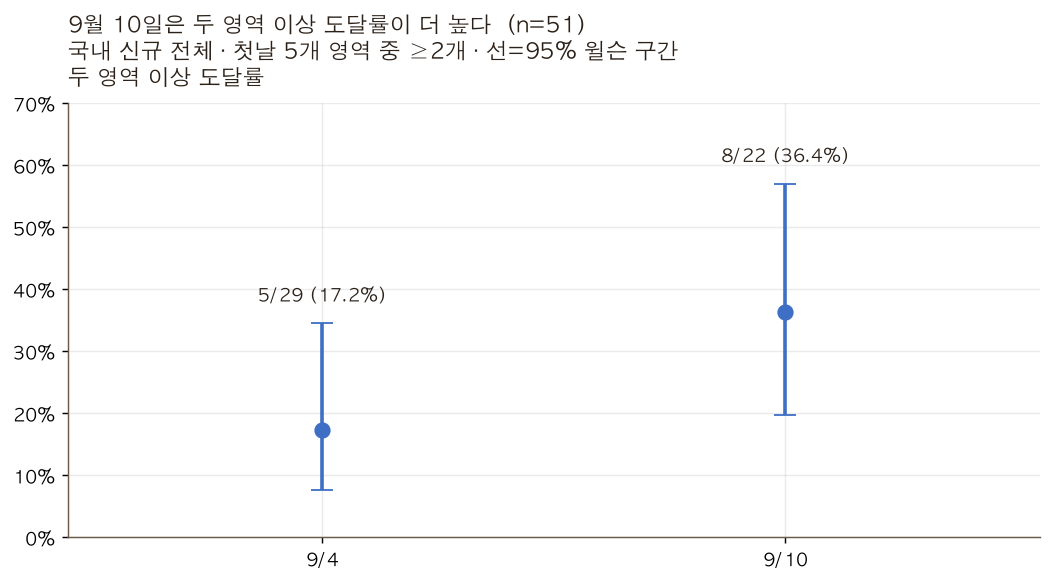

In [4]:
fig, ax = R.new('9월 10일은 두 영역 이상 도달률이 더 높다', len(domestic),
    sub='국내 신규 전체 · 첫날 5개 영역 중 ≥2개 · 선=95% 윌슨 구간',
    ylab='두 영역 이상 도달률', figsize=(8.2, 4.6))
x = np.arange(2)
y = summary.rate.to_numpy()
err = np.vstack([y-summary.ci_low.to_numpy(), summary.ci_high.to_numpy()-y])
ax.errorbar(x, y, yerr=err, fmt='o', capsize=6, markersize=8,
            color=R.PALETTE[1], linewidth=2)
for i, row in summary.iterrows():
    ax.text(i, row.ci_high+.035, f'{int(row.two_plus)}/{int(row.devices)} ({row.rate:.1%})',
            ha='center', fontsize=10)
ax.set_xticks(x, summary.cohort)
ax.set_xlim(-.55, 1.55)
ax.set_ylim(0, min(1.0, max(.7, float(summary.ci_high.max()+.13))))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
chart_rate = R.save(fig, ax, 'g2_domestic_two_plus_rate', zero_base=False)
print(R.check(chart_rate)); display(R.show(chart_rate))


## 5. 활동 영역 수 분포

분모를 행동자로 좁히지 않아 첫날 아무 행동도 기록되지 않은 기기가 그대로 보인다. 오른쪽 꼬리는 소수의 깊게 플레이한 기기다. 영역 수가 높다는 사실이 이벤트의 실제 **순서**를 알려주지는 않는다.

activity_area_count,0,1,2,3,4,5
9/4,17,7,2,0,0,3
9/10,12,2,2,0,2,4


g2_domestic_area_count_distribution.png  1183x585px


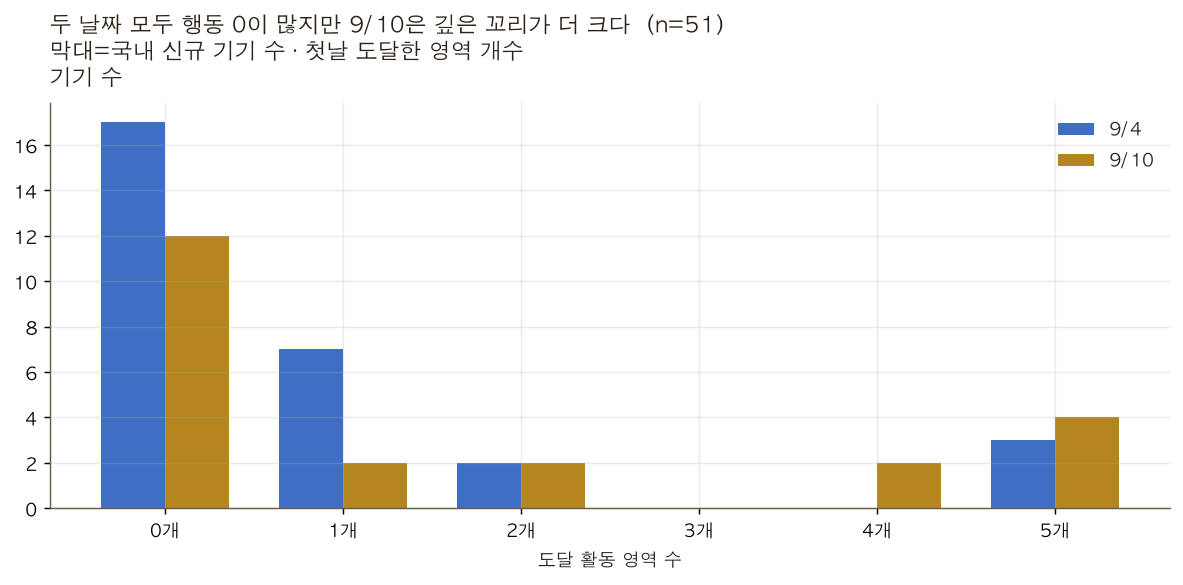

In [5]:
dist = pd.crosstab(domestic.cohort, domestic.activity_area_count).reindex(COHORTS).reindex(columns=range(6), fill_value=0)
dist.index = [SHORT[c] for c in COHORTS]
dist.to_csv(OUT/'area_count_distribution.csv')
display(dist)
fig, ax = R.new('두 날짜 모두 행동 0이 많지만 9/10은 깊은 꼬리가 더 크다', len(domestic),
    sub='막대=국내 신규 기기 수 · 첫날 도달한 영역 개수', ylab='기기 수', figsize=(9.2,4.6))
width = .36
ax.bar(np.arange(6)-width/2, dist.loc['9/4'], width, label='9/4', color=R.PALETTE[1])
ax.bar(np.arange(6)+width/2, dist.loc['9/10'], width, label='9/10', color=R.PALETTE[3])
ax.set_xticks(range(6), [f'{i}개' for i in range(6)])
ax.set_xlabel('도달 활동 영역 수')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
chart_dist = R.save(fig, ax, 'g2_domestic_area_count_distribution')
print(R.check(chart_dist)); display(R.show(chart_dist))


## 6. 영역별 도달

각 비율의 분모는 해당 날짜의 국내 신규 기기 전체다. 한 기기가 여러 영역에 들어가므로 비율 합계는 100%가 아니다. 개별 영역의 분자는 모두 한 자리수여서 **영역별 순위나 우열을 주장하지 않는다**.

,cohort,area,devices,cohort_devices,rate
0,9/4,자연·채집,6,29,0.206897
1,9/4,낚시·바다,4,29,0.137931
2,9/4,퀘스트·교류,6,29,0.206897
3,9/4,제작·집,3,29,0.103448
4,9/4,고급 콘텐츠,7,29,0.241379
5,9/10,자연·채집,9,22,0.409091
6,9/10,낚시·바다,5,22,0.227273
7,9/10,퀘스트·교류,9,22,0.409091
8,9/10,제작·집,6,22,0.272727
9,9/10,고급 콘텐츠,5,22,0.227273


g2_domestic_area_reach.png  1222x598px


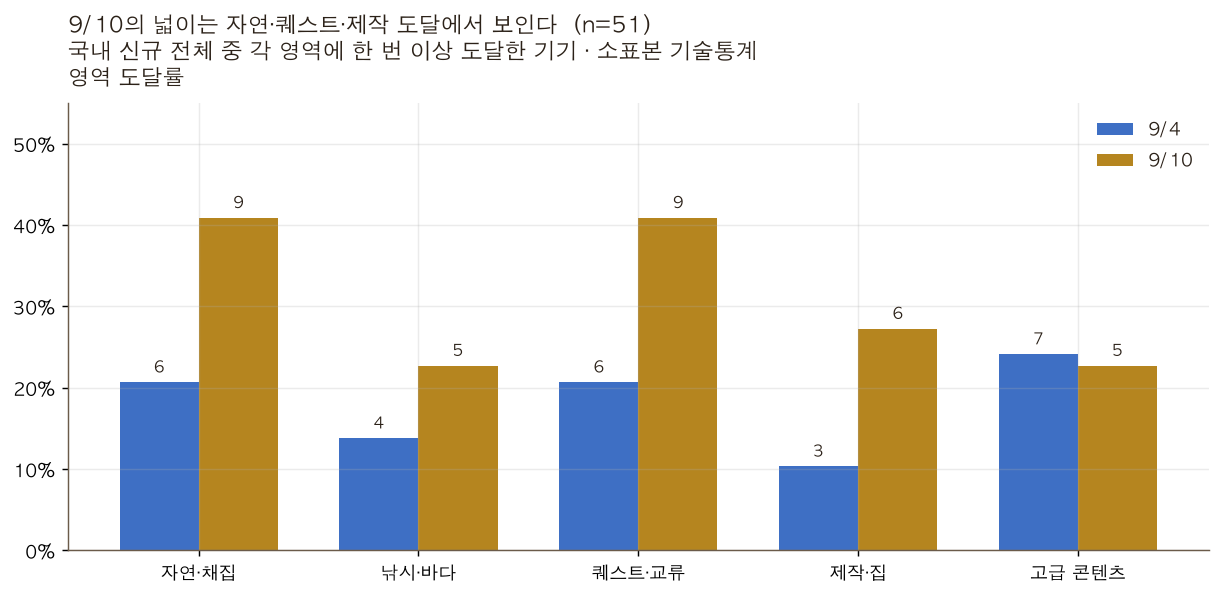

In [6]:
reach_rows=[]
for cohort in COHORTS:
    group = domestic[domestic.cohort.eq(cohort)]
    for field, label in AREAS.items():
        k = int(group[field].gt(0).sum())
        reach_rows.append(dict(cohort=SHORT[cohort], area=label, devices=k,
                               cohort_devices=len(group), rate=k/len(group)))
reach = pd.DataFrame(reach_rows)
reach.to_csv(OUT/'area_reach.csv', index=False)
display(reach)
fig, ax = R.new('9/10의 넓이는 자연·퀘스트·제작 도달에서 보인다', len(domestic),
    sub='국내 신규 전체 중 각 영역에 한 번 이상 도달한 기기 · 소표본 기술통계',
    ylab='영역 도달률', figsize=(9.5,4.7))
area_names=list(AREAS.values())
base=np.arange(len(area_names)); width=.36
for offset, cohort, color in [(-width/2,'9/4',R.PALETTE[1]),(width/2,'9/10',R.PALETTE[3])]:
    subset=reach[reach.cohort.eq(cohort)].set_index('area').loc[area_names]
    bars=ax.bar(base+offset, subset.rate, width, label=cohort, color=color)
    for bar, k in zip(bars, subset.devices):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.012,
                str(int(k)), ha='center', fontsize=9)
ax.set_xticks(base,area_names)
ax.set_ylim(0,.55)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
chart_reach=R.save(fig,ax,'g2_domestic_area_reach',zero_base=False)
print(R.check(chart_reach)); display(R.show(chart_reach))


## 7. 영역의 겹침

두 영역을 **같은 첫날에 모두** 경험한 기기 수다. 행·열 교차는 순서를 뜻하지 않는다. 대각선은 개별 영역 도달 기기 수이며, 내부 칸은 대부분 한 자리수라 특정 결합을 선호한다고 해석하면 안 된다. 날짜별로 독립된 PNG 한 장씩 그린다.

### 9/4 동시 도달 기기 수

,자연·채집,낚시·바다,퀘스트·교류,제작·집,고급 콘텐츠
자연·채집,6,3,4,3,3
낚시·바다,3,4,3,3,3
퀘스트·교류,4,3,6,3,4
제작·집,3,3,3,3,3
고급 콘텐츠,3,3,4,3,7


g2_domestic_overlap_94.png  773x663px


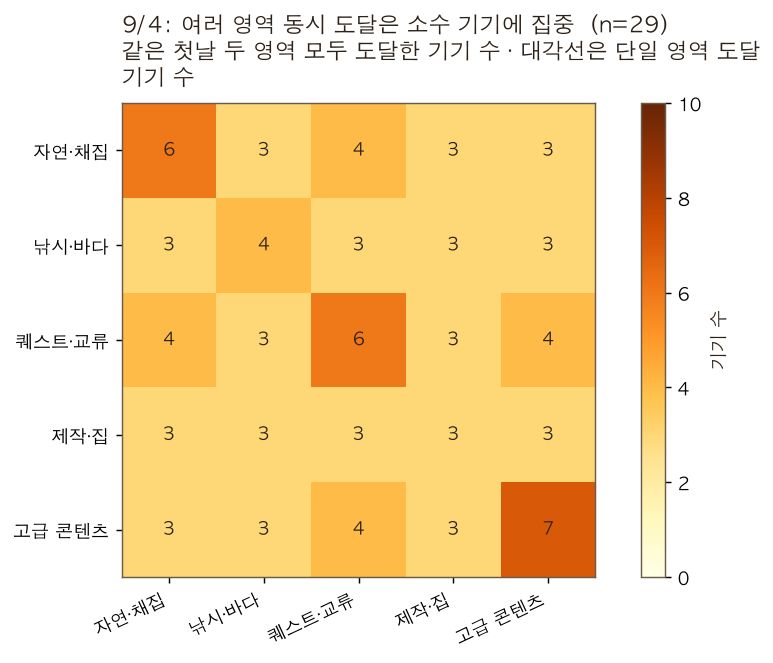

### 9/10 동시 도달 기기 수

,자연·채집,낚시·바다,퀘스트·교류,제작·집,고급 콘텐츠
자연·채집,9,5,8,6,5
낚시·바다,5,5,5,5,4
퀘스트·교류,8,5,9,6,5
제작·집,6,5,6,6,5
고급 콘텐츠,5,4,5,5,5


g2_domestic_overlap_910.png  773x663px


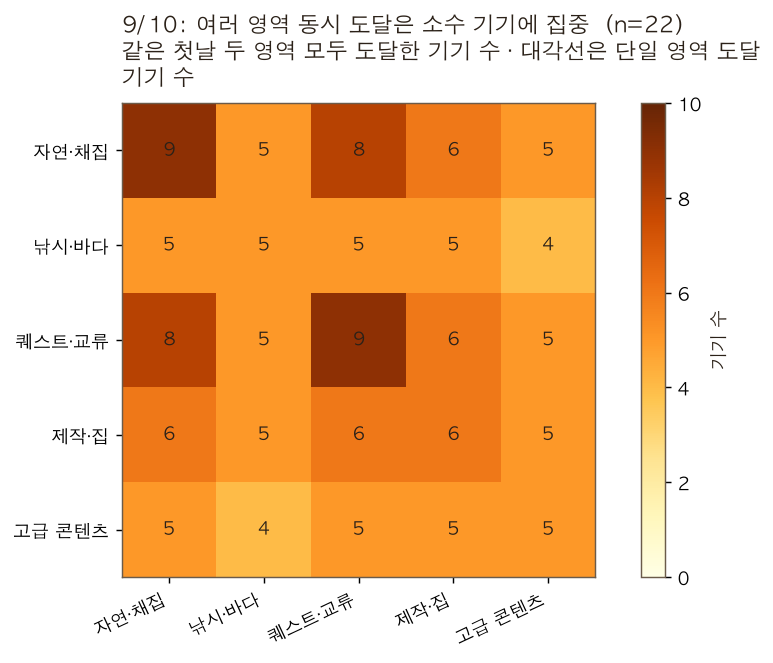

In [7]:
overlap_charts={}
for cohort in COHORTS:
    group=domestic[domestic.cohort.eq(cohort)]
    flags=group[list(AREAS)].gt(0).astype(int)
    mat=flags.T.dot(flags)
    mat.index=list(AREAS.values()); mat.columns=list(AREAS.values())
    mat.to_csv(OUT/f'overlap_{SHORT[cohort].replace("/", "")}.csv')
    display(Markdown(f'### {SHORT[cohort]} 동시 도달 기기 수'))
    display(mat)
    fig,ax=R.new(f'{SHORT[cohort]}: 여러 영역 동시 도달은 소수 기기에 집중',len(group),
        sub='같은 첫날 두 영역 모두 도달한 기기 수 · 대각선은 단일 영역 도달',
        ylab='기기 수',figsize=(7.5,5.2))
    im=ax.imshow(mat.to_numpy(),cmap='YlOrBr',vmin=0,vmax=10)
    ax.set_xticks(range(5),mat.columns,rotation=25,ha='right')
    ax.set_yticks(range(5),mat.index)
    for i in range(5):
        for j in range(5):
            ax.text(j,i,str(int(mat.iloc[i,j])),ha='center',va='center',fontsize=10)
    fig.colorbar(im,ax=ax,label='기기 수')
    ax.grid(False); fig.tight_layout()
    path=R.save(fig,ax,f'g2_domestic_overlap_{SHORT[cohort].replace("/", "")}',zero_base=False)
    overlap_charts[cohort]=path
    print(R.check(path)); display(R.show(path))


## 8. 심층 플레이 기기 제거 민감도

결과를 본 뒤 임계값을 고치지는 않는다. 다만 5개 영역을 모두 경험한 소수 기기가 분자를 얼마나 좌우하는지 별도로 재계산한다. 이 표는 **H3 본판의 대체 판정이 아니라 강건성 점검**이다.

,cohort,original_n,original_k,all_five,remaining_n,remaining_k,remaining_rate
0,9/4,29,5,3,26,2,0.076923
1,9/10,22,8,4,18,4,0.222222


5영역 전부 도달 기기 제외 후 차이: 14.5%p


g2_domestic_all_five_sensitivity.png  1079x585px


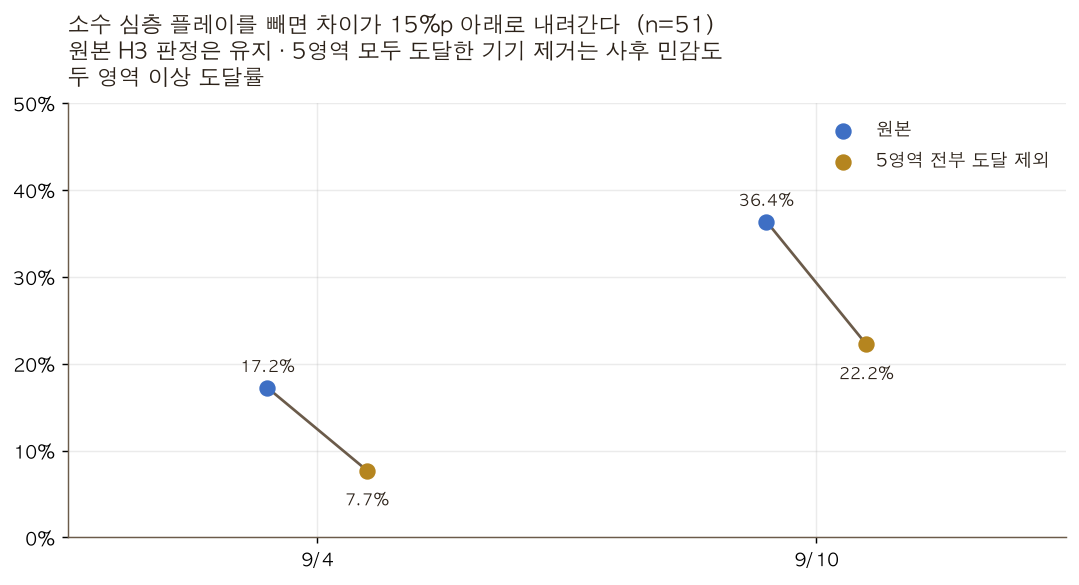

In [8]:
sensitivity=[]
for cohort in COHORTS:
    group=domestic[domestic.cohort.eq(cohort)]
    trim=group[group.activity_area_count.lt(5)]
    sensitivity.append(dict(cohort=SHORT[cohort],
        original_n=len(group), original_k=int(group.two_plus.sum()),
        all_five=int(group.activity_area_count.eq(5).sum()),
        remaining_n=len(trim), remaining_k=int(trim.two_plus.sum()),
        remaining_rate=float(trim.two_plus.mean())))
sensitivity=pd.DataFrame(sensitivity)
trim_delta=float(sensitivity.iloc[1].remaining_rate-sensitivity.iloc[0].remaining_rate)
sensitivity.to_csv(OUT/'all_five_sensitivity.csv',index=False)
display(sensitivity)
print(f'5영역 전부 도달 기기 제외 후 차이: {trim_delta*100:.1f}%p')
fig,ax=R.new('소수 심층 플레이를 빼면 차이가 15%p 아래로 내려간다',len(domestic),
    sub='원본 H3 판정은 유지 · 5영역 모두 도달한 기기 제거는 사후 민감도',
    ylab='두 영역 이상 도달률',figsize=(8.4,4.6))
for i,cohort in enumerate(['9/4','9/10']):
    original=summary.loc[summary.cohort.eq(cohort),'rate'].iloc[0]
    trimmed=sensitivity.loc[sensitivity.cohort.eq(cohort),'remaining_rate'].iloc[0]
    ax.plot([i-.10,i+.10],[original,trimmed],color=R.MUTED,linewidth=1.5)
    ax.scatter(i-.10,original,color=R.PALETTE[1],s=65,label='원본' if i==0 else None,zorder=3)
    ax.scatter(i+.10,trimmed,color=R.PALETTE[3],s=65,label='5영역 전부 도달 제외' if i==0 else None,zorder=3)
    ax.text(i-.10,original+.018,f'{original:.1%}',ha='center',fontsize=9)
    ax.text(i+.10,trimmed-.04,f'{trimmed:.1%}',ha='center',fontsize=9)
ax.set_xticks([0,1],['9/4','9/10'])
ax.set_xlim(-.5,1.5); ax.set_ylim(0,.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); chart_sensitivity=R.save(fig,ax,'g2_domestic_all_five_sensitivity',zero_base=False)
print(R.check(chart_sensitivity)); display(R.show(chart_sensitivity))


## 9. 기기 유형은 혼동 요인

9/4는 기존 분석에서 모바일이 압도적으로 많았다. H3의 영역 폭 차이를 날짜 자체의 효과로 읽지 않기 위해 기기별 분자·분모를 확인한다. 9/4 데스크톱처럼 n<10인 셀은 회색 참고치로만 취급한다.

,cohort,device,devices,two_plus,rate
0,9/4,desktop,4,0,0.0
1,9/4,mobile,25,5,0.2
2,9/10,desktop,9,3,0.333333
3,9/10,mobile,13,5,0.384615


g2_domestic_device_mix.png  1131x572px


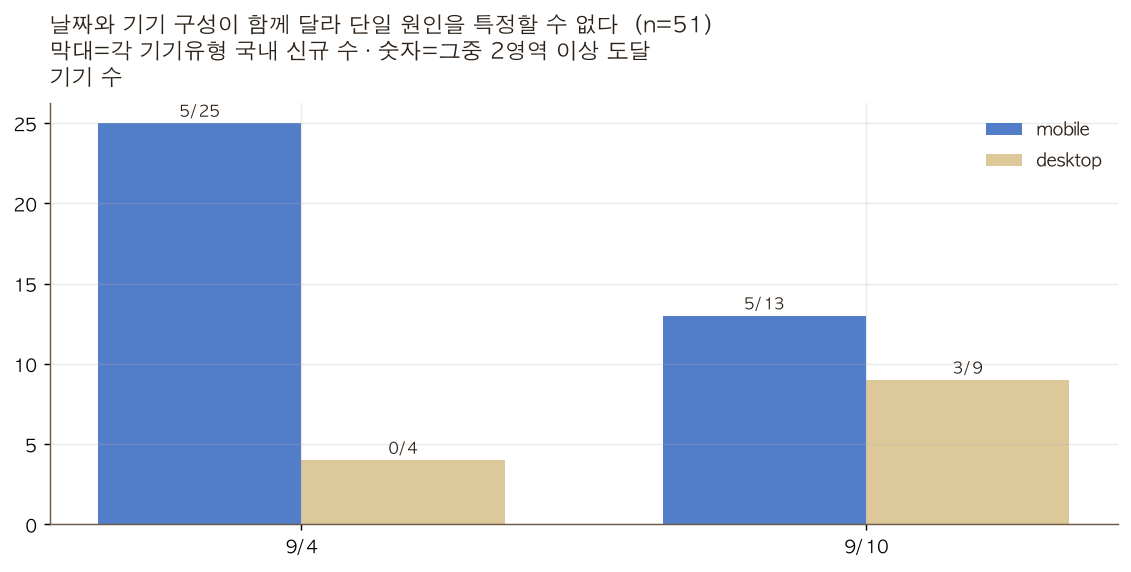

In [9]:
device = domestic.groupby(['cohort','device']).agg(
    devices=('two_plus','size'), two_plus=('two_plus','sum')).reset_index()
device['rate']=device.two_plus/device.devices
device['cohort']=device.cohort.map(SHORT)
device.to_csv(OUT/'device_cross_tab.csv',index=False)
display(device)
fig,ax=R.new('날짜와 기기 구성이 함께 달라 단일 원인을 특정할 수 없다',len(domestic),
    sub='막대=각 기기유형 국내 신규 수 · 숫자=그중 2영역 이상 도달',
    ylab='기기 수',figsize=(8.8,4.5))
positions=np.arange(2); width=.36
for offset, name, color in [(-width/2,'mobile',R.PALETTE[1]),(width/2,'desktop',R.PALETTE[3])]:
    values=[]; successes=[]
    for c in ['9/4','9/10']:
        row=device[(device.cohort==c)&(device.device==name)]
        values.append(int(row.devices.iloc[0]) if len(row) else 0)
        successes.append(int(row.two_plus.iloc[0]) if len(row) else 0)
    bars=ax.bar(positions+offset,values,width,color=color,label=name,
                alpha=.45 if min(values)<10 else .9)
    for bar,n,k in zip(bars,values,successes):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.4,
                f'{k}/{n}',ha='center',fontsize=9)
ax.set_xticks(positions,['9/4','9/10'])
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); chart_device=R.save(fig,ax,'g2_domestic_device_mix')
print(R.check(chart_device)); display(R.show(chart_device))


## 10. 그래서 크기가 얼마나 되나

아래 셀은 원시표에서 결론을 다시 생성한다. 특정 영역의 작은 셀 순위나 인과효과를 만들지 않는다.

In [10]:
display(Markdown(
    f'**한 줄 답:** 9/10 국내 신규는 {int(summary.iloc[1].two_plus)}/{int(summary.iloc[1].devices)}대 '
    f'({summary.iloc[1].rate:.1%}), 9/4는 {int(summary.iloc[0].two_plus)}/{int(summary.iloc[0].devices)}대 '
    f'({summary.iloc[0].rate:.1%})가 2개 이상 영역에 도달했다. 차이 **{delta*100:.1f}%p**로 '
    f'사전 기준 15%p를 {"넘어 H3를 채택한다" if h3_pass else "넘지 못해 H3를 기각한다"}.\n\n'
    f'행동 0은 9/4 {int(summary.iloc[0].no_area)}대, 9/10 {int(summary.iloc[1].no_area)}대다. '
    f'5개 영역을 모두 경험한 기기(각각 {int(sensitivity.iloc[0].all_five)}·'
    f'{int(sensitivity.iloc[1].all_five)}대)를 제외하면 차이는 {trim_delta*100:.1f}%p로 줄어 '
    '사전 기준에 못 미친다. 본판 채택과 별개로 결과가 취약하다는 뜻이다.'
))


**한 줄 답:** 9/10 국내 신규는 8/22대 (36.4%), 9/4는 5/29대 (17.2%)가 2개 이상 영역에 도달했다. 차이 **19.1%p**로 사전 기준 15%p를 넘어 H3를 채택한다.

행동 0은 9/4 17대, 9/10 12대다. 5개 영역을 모두 경험한 기기(각각 3·4대)를 제외하면 차이는 14.5%p로 줄어 사전 기준에 못 미친다. 본판 채택과 별개로 결과가 취약하다는 뜻이다.

## 11. 이 숫자로 말할 수 없는 것

- 9/4 국내 신규 29대, 9/10 22대뿐이다. 2영역 이상 분자도 각각 한 자리수다. 윌슨 구간이 겹칠 수 있으며 사전 **기술적** 기준 충족을 모집단 차이의 확증으로 읽지 않는다.
- 9/4는 모바일 중심이고 9/10은 데스크톱이 늘었다. **후속 플랫폼 감사에서 9/4에는 토스 기기 21대, 9/10에는 8대가 관측됐다.** 전체 날짜별 기기 수와 혼동하지 말 것. 당시 H3는 토스와 웹을 합친 비교였다. 플랫폼·버전·베타테스터 구성이 함께 달라질 수 있어 날짜가 행동 다양성을 일으켰다고 말할 수 없다.
- 첫 관측 국가는 실제 거주지가 아닐 수 있고, `user_pseudo_id`는 사람이 아니라 브라우저/기기에 가깝다.
- 각 영역은 이벤트 허용목록에 의존한다. 누락된 실제 행동이 있다면 영역 수가 낮아진다. 자동·부수 이벤트를 제외한 이유도 이 정의에 따른다.
- 이벤트 timestamp 동률이 많아 **경로·순서·퍼널**은 복원하지 않았다. 겹침은 동시 경험 여부이지 행동의 선후관계가 아니다.
- 유급 베타테스터를 안정적으로 식별·제외하지 못했다. 5영역 모두 도달 기기 제외 시 차이가 15%p 아래로 내려가므로, 소수의 깊은 플레이가 결과를 실제로 좌우한다.
- 분석 종료일을 9/11로 고정해 재현성을 우선했다. 이후 늦게 도착한 과거 이벤트가 있으면 재실행 수치가 달라질 수 있다.

## 12. 다음에 확인할 것

이 H3가 기각되더라도 정상 결과다. 깊은 플레이가 테스터·개발자에 집중됐는지 검증하려면 **명시적 표식의 커버리지부터** 확인해야 한다. 현재 로그의 시간 동률을 해결하려면 클라이언트 증가 시퀀스 번호를 새 이벤트에 추가하는 계측 작업이 필요하다. 두 과제는 별도 승인 전까지 시작하지 않는다.

## 13. 분석 가정 기록

| 가정 | 근거 | 확신 | 틀렸을 때 영향 | 검증 계획 |
|---|---|---|---|---|
| 첫 이벤트 국가로 국내 신규를 정의 | GA4 기기 최초 관측 속성 | 중 | 표본 이동 | 국가/언어/캠페인 교차 점검 |
| 의도적 행동 허용목록이 실제 플레이를 대체 | 기존 02 노트북에서 감사 | 중 | 영역 수 과소·왜곡 | 새 이벤트 추가분을 코드와 대조 |
| 9/11 이전 export가 비교에 충분 | 양 날짜가 기간 안에 포함 | 높음 | 늦은 이벤트로 소폭 이동 | 재실행 시 n·분자 대조 |
| 베타테스터 혼입이 날짜 비교를 바꿀 수 있음 | 국내 소수 심층 플레이 | 낮음 | 높음 | 동의된 테스터 표식의 커버리지 점검 후 민감도 분석 |
| 기기별 관측은 독립 사용자와 다름 | 쿠키·멀티기기 가능 | 높음 | 불확실성 축소 | 계정-기기 안정 매핑 전까지 기술통계만 제시 |

마지막 가정은 미검증·고영향이므로 결론은 **탐색적**으로 제한한다.

## 14. W&B 실행 기록

집계 CSV와 개별 PNG 및 SQL만 artifact에 포함한다. 익명 기기별 행이나 식별자를 W&B에 올리지 않는다. 재실행은 기존 run ID를 재개한다.

In [11]:
run_file=OUT/'wandb_run_id.txt'
images={'two_plus':chart_rate,'area_distribution':chart_dist,
        'area_reach':chart_reach,'all_five_sensitivity':chart_sensitivity,
        'device_mix':chart_device}
images.update({f'overlap_{SHORT[c].replace("/", "")}':p for c,p in overlap_charts.items()})
kwargs={'project':tracking.PROJECT}
if run_file.exists():
    kwargs.update(id=run_file.read_text().strip(),resume='must')
else:
    kwargs.update(name='g2-domestic-spike-breadth',tags=['gate','eda','h3'])
with tracking.wandb.init(**kwargs) as run:
    run.summary['sep04_domestic_n']=int(summary.iloc[0].devices)
    run.summary['sep10_domestic_n']=int(summary.iloc[1].devices)
    run.summary['sep04_two_plus']=int(summary.iloc[0].two_plus)
    run.summary['sep10_two_plus']=int(summary.iloc[1].two_plus)
    run.summary['difference_pp']=delta*100
    run.summary['h3_result']='accepted' if h3_pass else 'rejected'
    run.log({k:tracking.wandb.Image(str(p)) for k,p in images.items()})
    artifact=tracking.wandb.Artifact('g2-domestic-spike-breadth',type='analysis')
    for path in OUT.glob('*.csv'):
        artifact.add_file(str(path))
    artifact.add_file(str(SQL),name=f'sql/{SQL.name}')
    artifact.add_file(str(OUT/'assumptions.json'))
    for path in images.values():
        artifact.add_file(str(path),name=f'figs/{path.name}')
    run.log_artifact(artifact)
    run_file.write_text(run.id,encoding='utf-8')
    print('W&B run:',run.url)
    print('W&B run id:',run.id)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: icucheol to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run yueyxcti


wandb: Tracking run with wandb version 0.28.2


wandb: Run data is saved locally in /Users/uicheol_hwang/calm_forest/wandb/run-20260914_125225-yueyxcti
wandb: Run `wandb offline` to turn off syncing.


...

wandb: uploading media/images/device_mix_2_d5f183b41321770e3f2f.png; uploading media/images/overlap_910_2_dae016ddd213fccda0db.png; uploading config.yaml; uploading wandb-metadata.json; uploading media/images/two_plus_2_993e6aca805a0ecd374a.png (+ 6 more)


wandb: uploading history steps 2-2, summary


wandb: 
wandb: Run summary:
wandb:    difference_pp 19.12226
wandb:        h3_result accepted
wandb: sep04_domestic_n 29
wandb:   sep04_two_plus 5
wandb: sep10_domestic_n 22
wandb:   sep10_two_plus 8
wandb: 


wandb: 🚀 View run g2-domestic-spike-breadth at: https://wandb.ai/icucheol/calm-forest/runs/yueyxcti
wandb: ⭐️ View project at: https://wandb.ai/icucheol/calm-forest
wandb: Synced 4 W&B file(s), 7 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260914_125225-yueyxcti/logs
